In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [3]:
PATH = "green_tripdata_2021-01.parquet"
df = pd.read_parquet(PATH)

print("Shape:", df.shape)
df.head()

Shape: (76518, 20)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [4]:
df.info()

display(df.describe(include="all").T.head(30))

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing[missing > 0].to_frame("missing_%").head(30))

<class 'pandas.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               76518 non-null  int64         
 1   lpep_pickup_datetime   76518 non-null  datetime64[us]
 2   lpep_dropoff_datetime  76518 non-null  datetime64[us]
 3   store_and_fwd_flag     40471 non-null  str           
 4   RatecodeID             40471 non-null  float64       
 5   PULocationID           76518 non-null  int64         
 6   DOLocationID           76518 non-null  int64         
 7   passenger_count        40471 non-null  float64       
 8   trip_distance          76518 non-null  float64       
 9   fare_amount            76518 non-null  float64       
 10  extra                  76518 non-null  float64       
 11  mta_tax                76518 non-null  float64       
 12  tip_amount             76518 non-null  float64       
 13  tolls_amount

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
VendorID,76518.0,NaN,NaN,NaN,1.90529,1.0,2.0,2.0,2.0,2.0,0.292816
lpep_pickup_datetime,76518,NaN,NaN,NaN,2021-01-16 15:52:22.173018,2009-01-01 00:03:25,2021-01-08 23:22:00,2021-01-16 10:11:45,2021-01-24 09:41:04.250000,2021-01-31 23:46:45,NaN
lpep_dropoff_datetime,76518,NaN,NaN,NaN,2021-01-16 16:12:17.846781,2009-01-01 00:12:25,2021-01-08 23:42:32,2021-01-16 10:30:42.500000,2021-01-24 09:55:45,2021-02-01 16:56:37,NaN
store_and_fwd_flag,40471,2,N,40205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RatecodeID,40471.0,NaN,NaN,NaN,1.143041,1.0,1.0,1.0,1.0,99.0,0.878693
PULocationID,76518.0,NaN,NaN,NaN,109.590371,1.0,55.0,76.0,166.0,265.0,71.063053
DOLocationID,76518.0,NaN,NaN,NaN,130.685577,1.0,65.0,129.0,197.0,265.0,77.101641
passenger_count,40471.0,NaN,NaN,NaN,1.192311,0.0,1.0,1.0,1.0,8.0,0.756395
trip_distance,76518.0,NaN,NaN,NaN,40.862552,0.0,1.3,2.59,5.76,244152.01,1924.408778
fare_amount,76518.0,NaN,NaN,NaN,19.939777,-280.0,9.0,16.73,25.5,284.0,14.984241


,missing_%
ehail_fee,100.00
congestion_surcharge,47.11
trip_type,47.11
store_and_fwd_flag,47.11
RatecodeID,47.11
payment_type,47.11
passenger_count,47.11


In [6]:
# Convert to datetime if present
for c in ["lpep_pickup_datetime", "lpep_dropoff_datetime"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Trip duration in minutes (if both columns exist)
if {"lpep_pickup_datetime", "lpep_dropoff_datetime"}.issubset(df.columns):
    df["trip_duration_min"] = (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]).dt.total_seconds() / 60
    print("Created trip_duration_min")
else:
    print("Pickup/dropoff datetime columns not found; skipping trip_duration_min")

Created trip_duration_min


In [7]:
key_numeric = [c for c in ["trip_distance", "fare_amount", "total_amount", "trip_duration_min", "passenger_count"] if c in df.columns]
df[key_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
trip_distance,76518.0,40.862552,1924.408778,0.0,1.3,2.590000,5.76,244152.01
fare_amount,76518.0,19.939777,14.984241,-280.0,9.0,16.730000,25.50,284.00
total_amount,76518.0,23.574820,16.361991,-280.3,11.8,20.640000,29.32,294.51
trip_duration_min,76518.0,19.927896,59.338594,0.0,8.0,13.883333,23.00,1439.60
passenger_count,40471.0,1.192311,0.756395,0.0,1.0,1.000000,1.00,8.00


In [8]:
df_eda = df.copy()

# Drop rows with missing critical values
critical_cols = [c for c in ["trip_distance", "fare_amount"] if c in df_eda.columns]
df_eda = df_eda.dropna(subset=critical_cols)

# Clean numeric columns if present
if "trip_distance" in df_eda.columns:
    df_eda = df_eda[(df_eda["trip_distance"] > 0) & (df_eda["trip_distance"] < 100)]

if "fare_amount" in df_eda.columns:
    df_eda = df_eda[(df_eda["fare_amount"] > 0) & (df_eda["fare_amount"] < 300)]

if "trip_duration_min" in df_eda.columns:
    df_eda = df_eda[(df_eda["trip_duration_min"] > 0) & (df_eda["trip_duration_min"] < 300)]

if "passenger_count" in df_eda.columns:
    df_eda = df_eda[(df_eda["passenger_count"] >= 1) & (df_eda["passenger_count"] <= 8)]

print("Original:", df.shape, "EDA cleaned:", df_eda.shape)
df_eda.head()

Original: (76518, 21) EDA cleaned: (38047, 21)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_duration_min
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,...,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,...,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,...,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,...,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.5,...,0.5,0.96,0.0,None,0.3,5.76,1.0,1.0,0.00,2.316667


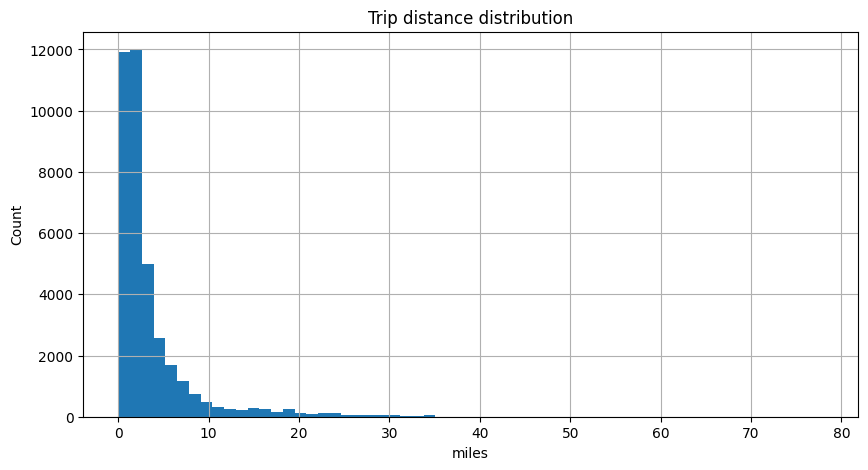

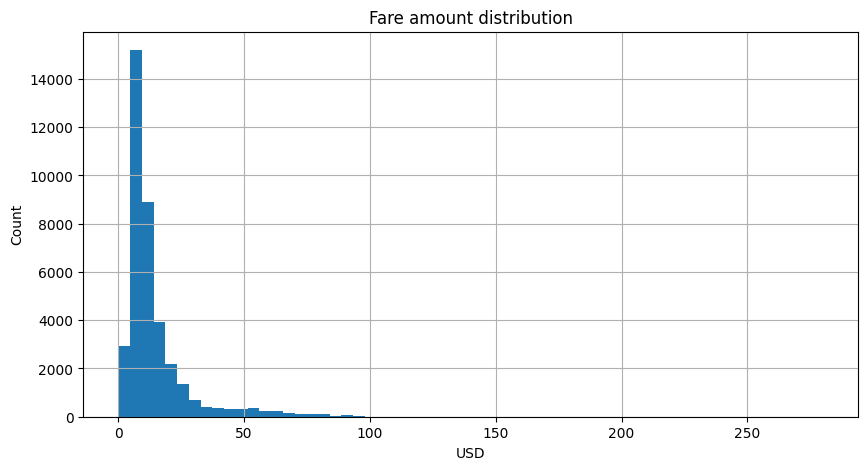

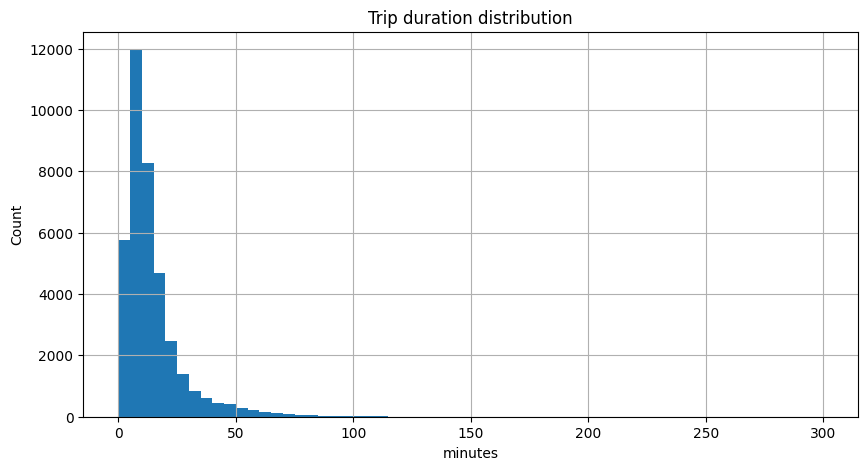

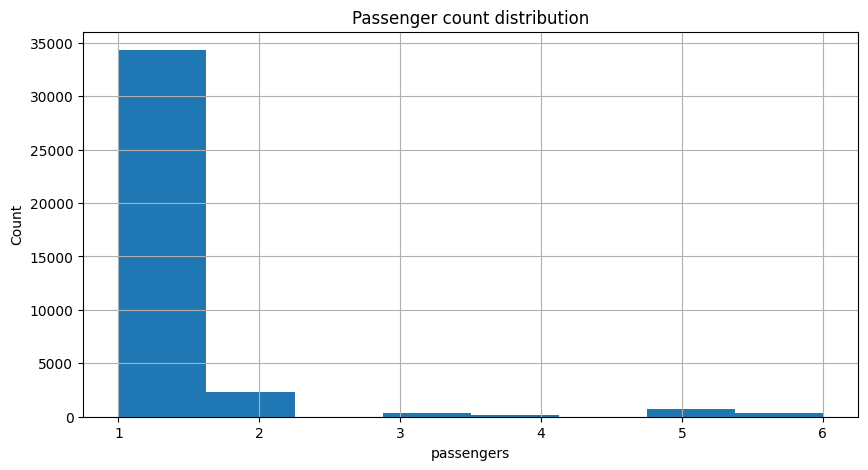

In [9]:
def hist_plot(series, title, bins=50, xlabel=None):
    s = series.dropna()
    plt.figure()
    plt.hist(s, bins=bins)
    plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

if "trip_distance" in df_eda.columns:
    hist_plot(df_eda["trip_distance"], "Trip distance distribution", bins=60, xlabel="miles")

if "fare_amount" in df_eda.columns:
    hist_plot(df_eda["fare_amount"], "Fare amount distribution", bins=60, xlabel="USD")

if "trip_duration_min" in df_eda.columns:
    hist_plot(df_eda["trip_duration_min"], "Trip duration distribution", bins=60, xlabel="minutes")

if "passenger_count" in df_eda.columns:
    # passenger_count is discrete; show bar-like histogram
    hist_plot(df_eda["passenger_count"], "Passenger count distribution", bins=8, xlabel="passengers")

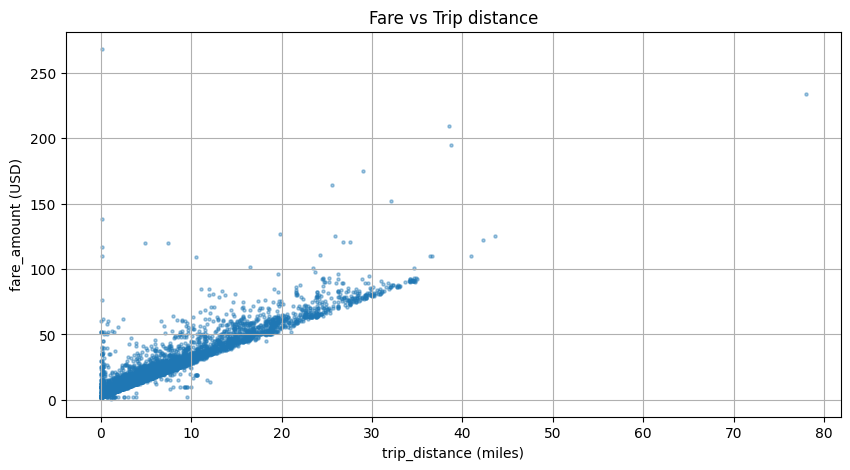

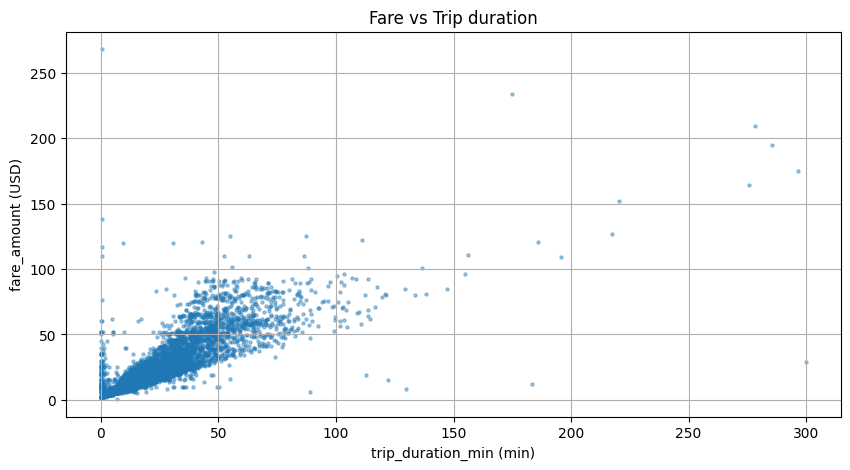

In [10]:
def scatter(x, y, title, xlabel=None, ylabel=None, sample=20000):
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(tmp) > sample:
        tmp = tmp.sample(sample, random_state=42)
    plt.figure()
    plt.scatter(tmp["x"], tmp["y"], s=5, alpha=0.4)
    plt.title(title)
    plt.xlabel(xlabel or "x")
    plt.ylabel(ylabel or "y")
    plt.show()

if {"trip_distance", "fare_amount"}.issubset(df_eda.columns):
    scatter(df_eda["trip_distance"], df_eda["fare_amount"],
            "Fare vs Trip distance", xlabel="trip_distance (miles)", ylabel="fare_amount (USD)")

if {"trip_duration_min", "fare_amount"}.issubset(df_eda.columns):
    scatter(df_eda["trip_duration_min"], df_eda["fare_amount"],
            "Fare vs Trip duration", xlabel="trip_duration_min (min)", ylabel="fare_amount (USD)")

In [11]:
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[num_cols].corr()

# Show strongest correlations with fare_amount if present
if "fare_amount" in corr.columns:
    display(corr["fare_amount"].sort_values(ascending=False).to_frame("corr_with_fare_amount"))

corr

,corr_with_fare_amount
fare_amount,1.000000
total_amount,0.984028
trip_distance,0.942037
trip_duration_min,0.848623
tolls_amount,0.563130
tip_amount,0.217997
PULocationID,0.217924
DOLocationID,0.099750
RatecodeID,0.087011
VendorID,0.085092


,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_duration_min
VendorID,1.000000,0.043583,0.013466,-0.000213,0.044541,0.083446,0.085092,-0.410509,-0.039994,-0.006694,0.069355,0.075020,0.078657,-0.048443,0.042090,-0.032679,0.068822
RatecodeID,0.043583,1.000000,0.060794,0.023735,0.017460,0.020919,0.087011,-0.084228,-0.962258,-0.023167,0.016764,-0.199067,0.066103,0.025813,0.906531,-0.051166,0.008207
PULocationID,0.013466,0.060794,1.000000,0.151538,0.000247,0.227095,0.217924,0.005976,-0.057358,0.097663,0.113654,-0.014255,0.220193,-0.043359,0.055540,0.008871,0.161625
DOLocationID,-0.000213,0.023735,0.151538,1.000000,-0.011552,0.105077,0.099750,0.125273,-0.020511,0.147183,0.029500,-0.004245,0.141961,-0.103751,0.019549,0.406782,0.090469
passenger_count,0.044541,0.017460,0.000247,-0.011552,1.000000,-0.005763,-0.013359,-0.011532,-0.019758,0.007405,-0.011511,-0.009536,-0.012155,0.011717,0.023545,0.000378,-0.014417
trip_distance,0.083446,0.020919,0.227095,0.105077,-0.005763,1.000000,0.942037,0.000872,-0.002094,0.211595,0.597700,-0.011003,0.935611,-0.178156,-0.009491,0.061730,0.770147
fare_amount,0.085092,0.087011,0.217924,0.099750,-0.013359,0.942037,1.000000,-0.006395,-0.067516,0.217997,0.563130,-0.013668,0.984028,-0.180346,0.060668,0.044936,0.848623
extra,-0.410509,-0.084228,0.005976,0.125273,-0.011532,0.000872,-0.006395,1.000000,0.082652,0.119285,-0.043990,0.014936,0.044970,-0.085200,-0.079520,0.313030,0.008889
mta_tax,-0.039994,-0.962258,-0.057358,-0.020511,-0.019758,-0.002094,-0.067516,0.082652,1.000000,0.026644,-0.012521,0.211422,-0.047616,-0.022057,-0.936194,0.048781,0.002729
tip_amount,-0.006694,-0.023167,0.097663,0.147183,0.007405,0.211595,0.217997,0.119285,0.026644,1.000000,0.081709,0.010166,0.358138,-0.550638,-0.036777,0.305159,0.187419


In [12]:
candidate_cats = [c for c in ["VendorID", "RatecodeID", "payment_type", "trip_type", "store_and_fwd_flag"] if c in df_eda.columns]
for c in candidate_cats:
    print("\n", c)
    display(df_eda[c].value_counts(dropna=False).head(20))


 VendorID


VendorID
2    32053
1     5994
Name: count, dtype: int64


 RatecodeID


RatecodeID
1.0    37112
5.0      869
2.0       33
4.0       29
3.0        4
Name: count, dtype: int64


 payment_type


payment_type
1.0    22892
2.0    14987
3.0      123
4.0       44
5.0        1
Name: count, dtype: int64


 trip_type


trip_type
1.0    37288
2.0      759
Name: count, dtype: int64


 store_and_fwd_flag


store_and_fwd_flag
N    37835
Y      212
Name: count, dtype: int64

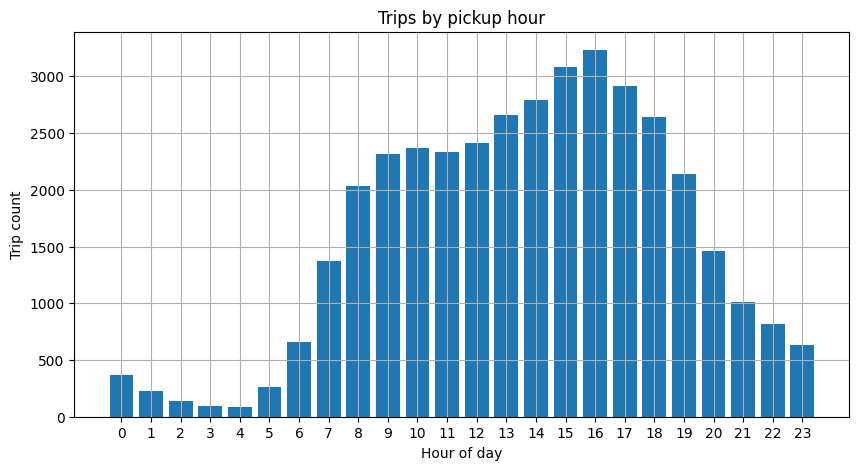

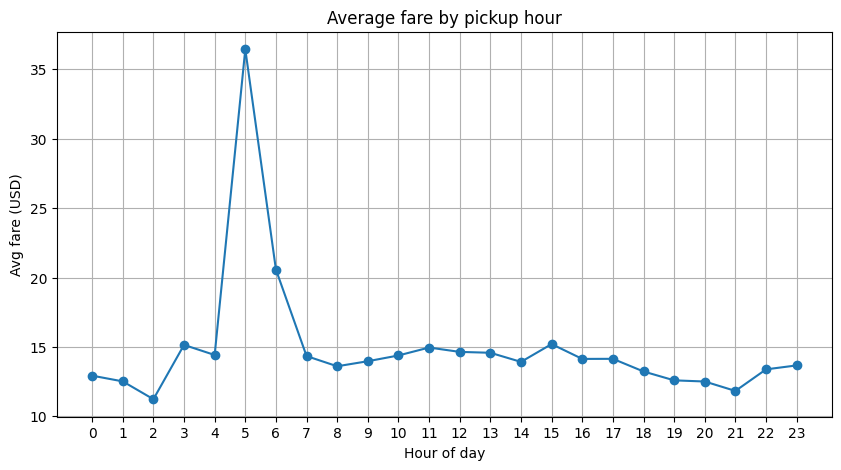

In [13]:
if "lpep_pickup_datetime" in df_eda.columns:
    df_eda["pickup_hour"] = df_eda["lpep_pickup_datetime"].dt.hour
    counts = df_eda["pickup_hour"].value_counts().sort_index()

    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.title("Trips by pickup hour")
    plt.xlabel("Hour of day")
    plt.ylabel("Trip count")
    plt.xticks(range(0, 24))
    plt.show()

    if "fare_amount" in df_eda.columns:
        hourly_mean_fare = df_eda.groupby("pickup_hour")["fare_amount"].mean()
        plt.figure()
        plt.plot(hourly_mean_fare.index, hourly_mean_fare.values, marker="o")
        plt.title("Average fare by pickup hour")
        plt.xlabel("Hour of day")
        plt.ylabel("Avg fare (USD)")
        plt.xticks(range(0, 24))
        plt.show()
else:
    print("No lpep_pickup_datetime column found; skipping time-based EDA.")

In [14]:
print("Suggested regression target options (if present):")
for t in ["fare_amount", "total_amount", "trip_duration_min"]:
    if t in df_eda.columns:
        print(" -", t)

# Candidate features you can pick from (choose 2-4 later)
candidate_features = []
for c in ["trip_distance", "trip_duration_min", "passenger_count", "pickup_hour", "RatecodeID", "payment_type", "trip_type", "VendorID"]:
    if c in df_eda.columns:
        candidate_features.append(c)

print("\nCandidate features present in dataset:")
print(candidate_features)

# Suggested binary classification target example:
# Long trip = duration >= threshold (use a percentile so it adapts to data)
if "trip_duration_min" in df_eda.columns:
    thr = float(df_eda["trip_duration_min"].quantile(0.75))
    print(f"\nExample classification target: is_long_trip = trip_duration_min >= {thr:.1f} minutes (75th percentile)")

Suggested regression target options (if present):
 - fare_amount
 - total_amount
 - trip_duration_min

Candidate features present in dataset:
['trip_distance', 'trip_duration_min', 'passenger_count', 'pickup_hour', 'RatecodeID', 'payment_type', 'trip_type', 'VendorID']

Example classification target: is_long_trip = trip_duration_min >= 17.4 minutes (75th percentile)


In [15]:
# Optional: save a smaller sample for faster experimentation
sample_path = "eda_sample.csv"
df_eda.sample(min(len(df_eda), 50000), random_state=42).to_csv(sample_path, index=False)
print("Saved sample to:", sample_path)

Saved sample to: eda_sample.csv
